# P2: BFS & DFS

**FIT1061 Introduction to Artificial Intelligence — Week 2**

In 1997, IBM's Deep Blue defeated world chess champion Garry Kasparov by exploring millions of positions using tree search. This week you'll build **breadth-first search (BFS)** — which explores layer by layer and guarantees the shortest path — and **depth-first search (DFS)** — which dives along one branch and finds *a* path, not necessarily the shortest. The two algorithms differ by a single decision: queue vs stack.

**This notebook covers all five sub-parts: P2.1 (hand trace), P2.2 (BFS implementation), P2.3 (DFS implementation), P2.4 (BFS vs DFS comparison), and P2.5 (reflection).** Your personalised hand-trace instance is generated below in Part 0 — trace it on paper there, then photograph it for P2.1.

**Pre-reading:** If you haven't already, read `P2_preread_stacks_queues.md` to understand what queues and stacks are and why this single data-structure swap changes the algorithm's behaviour.

> **🗣 Milestone task.** P2 requires a tutor discussion for sign-off. After completing all parts (including the hand trace, both implementations, the comparison table, and the reflection), book a discussion with your tutor.

> **P2.1 is personalised by your Monash student ID** — see the 'Your personalised instance' section below.


---

## Setup

Run the cell below to import the helper classes. These are defined in `p2_helpers.py` (in the same folder as this notebook). **You do not need to modify `p2_helpers.py`.**

In [44]:
from p2_helpers import (Queue, Stack, GridWorld, reconstruct_path,
                        draw_hand_trace_graph, HAND_TRACE_GRAPH,
                        make_dead_end_grid)
print("Imports OK.")


Imports OK.


---

## Warm-up: the trace from the whiteboard

In the lecture we traced **BFS from S to G** on the 7-node graph below. Work through it yourself
to warm up, then trace BFS on your own graph in Part 0.

Stuck? This is the exact graph we built the trace on in the lecture: revisit the slides or the workshop.

**The graph (undirected):**

```
S – {A, B}     A – {S, C, D}     B – {S, D, E}
C – {A, G}     D – {A, B, G}     E – {B}     G – {C, D}
```

Run BFS from **S** to **G**. At each step, record the node you dequeue, the frontier after adding
its unvisited neighbours, and the visited set. The first step is done for you:

| Step | Dequeue | Frontier after | Visited after |
|---|---|---|---|
| 1 | S | [A, B] | {S, A, B} |
| 2 | ? | ? | ? |
| 3 | ? | ? | ? |
| ... | | | |

- What is the **shortest path** from S to G? (Reconstruct it from the `came_from` links.)

*(Part 0 below is the SAME kind of BFS trace, but on a DIFFERENT 7-node graph — your own personalised start and goal.)*


---

## Your personalised instance (P2.1)

BFS hand trace is **personalised** for this task. Each student gets a different `(start, goal)` pair on the same 7-node graph. Your hand trace and reflection must use YOUR instance.

**Set your Monash student ID below**, then run the next two cells. Do not edit `task_instances.py`.


In [45]:
# Replace the placeholder with your Monash student ID (8 digits).
STUDENT_ID = "37524720"

assert STUDENT_ID.isdigit() and len(STUDENT_ID) == 8, (
    "Set STUDENT_ID to your 8-digit Monash student ID (digits only, in quotes)."
)


In [46]:
# Integrity check + instance generation.
# DO NOT EDIT task_instances.py — your tutor regenerates from your ID
# and compares fingerprints. Modifications will be caught.

from task_instances_lib import fingerprint
from task_instances import generate_instance

instance = generate_instance(STUDENT_ID)
trace = instance["trace"]

print(f"Student ID:                {STUDENT_ID}")
print(f"task_instances.py SHA-256: {fingerprint('task_instances.py')}")
print(f"Your (start, goal):        ({trace.start}, {trace.goal})")


Student ID:                37524720
task_instances.py SHA-256: ea923dd19964913b05d987f832254b18c5c510ff84ff238c18f14636cc890e3a
Your (start, goal):        (c, S)


---

## Part 0: The hand-trace graph (P2.1)

You were given a personalised `(start, goal)` pair above (the **Your personalised instance** section). Run the cell below to render the 7-node graph with YOUR start (green) and YOUR goal (red) highlighted.

**Before coding**, hand-trace BFS on YOUR graph from YOUR start to YOUR goal:

1. At each step, record the **current node** (dequeued from the frontier).
2. List the **frontier contents** after adding neighbours.
3. List the **visited set** after this step.
4. List the **exploration order** so far.

Photograph your hand trace: this is the P2.1 deliverable.

> **Different students get different start/goal pairs.** Your trace will look different from a peer's. Tutors regenerate from your Monash ID to verify.


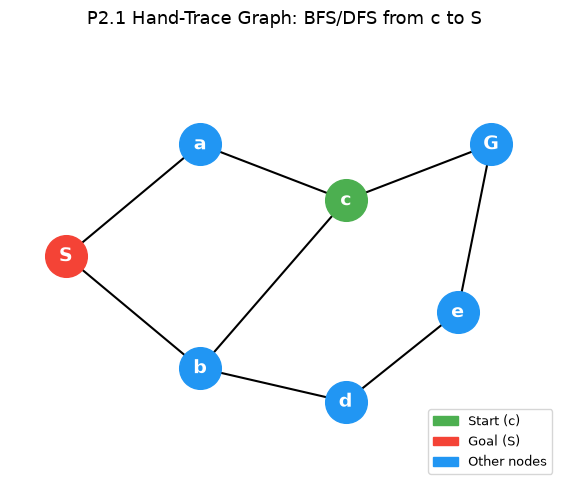

Start: c
Goal:  S

Graph adjacency list:
  S -> ['a', 'b']
  a -> ['S', 'c']
  b -> ['S', 'c', 'd']
  c -> ['G', 'a', 'b']
  d -> ['b', 'e']
  e -> ['G', 'd']
  G -> ['c', 'e']


In [47]:
draw_hand_trace_graph(graph=trace.graph, start=trace.start, goal=trace.goal)

print(f"Start: {trace.start}")
print(f"Goal:  {trace.goal}")
print("\nGraph adjacency list:")
for node, neighbours in trace.graph.items():
    print(f"  {node} -> {neighbours}")


---

### Articulation (P2.1: graded with the photo)

Answer these about YOUR instance. Numbers and node labels differ from a peer's, so generic AI-written answers will not match.

1. What is YOUR `(start, goal)` pair?
2. From your start, which node does BFS expand **first**? Why? (Hint: it's the first dequeued neighbour after sorting.)
3. List the BFS **exploration order** from your hand trace (the order nodes are dequeued).
4. What path did BFS return? How many edges long?
5. Did BFS find the **shortest** path? Why does BFS guarantee this?

Write your answers in the cell below, then photograph your hand trace and answers together for the P2.1 submission.


In [48]:
# Articulation answers — type your responses here.
# Reference YOUR (start, goal) pair printed above. Be specific.

answers = {
    "start": 'c',                # e.g. "d"
    "goal": 'S',                 # e.g. "G"
    "first_expanded_after_start": 'G',  # node label
    "expansion_order": ['c','G', 'a', 'b', 'e', 'S' ],      # list, e.g. ["d", "b", "e", "S", "c", "G"]
    "path": ['c', 'a','S'],                 # list, e.g. ["d", "e", "G"]
    "path_edges": 2,           # int
    "found_shortest": True,       # True or False
}

# Brief explanation (2-3 sentences) — why BFS expanded nodes in this order,
# referencing your start/goal:
explanation = """
BFS find the shortest path by going through every option, and end when they reach the target. 
"""

# Sanity checks (only verify the cell is filled, not correctness).
for k, v in answers.items():
    assert v is not None, f"answers['{k}'] is still None"
assert explanation.strip() != "TYPE YOUR EXPLANATION HERE.", "Write your explanation."
print("Filled in. Photograph hand trace + this cell for P2.1.")


Filled in. Photograph hand trace + this cell for P2.1.


---

## Part 1: Explore the data structures

Before implementing BFS, let's make sure you understand the tools you'll use.

### 1a: Queue

Run the cell below to see how the Queue class works. **Read the output carefully:** this is the data structure that drives BFS.

In [49]:
q = Queue()
print(f"Empty? {q.is_empty()}")  # True

q.enqueue("A")
q.enqueue("B")
q.enqueue("C")
print(f"After enqueuing A, B, C: {q}")

first = q.dequeue()
print(f"Dequeued: {first}")  # Should be "A" (FIFO!)
print(f"Remaining: {q}")

Empty? True
After enqueuing A, B, C: Queue(['A', 'B', 'C'])
Dequeued: A
Remaining: Queue(['B', 'C'])


**Checkpoint:** The cell above should show that dequeue returns `"A"` (the *first* item added). This is FIFO (First In, First Out). If you're unsure why, re-read the pre-reading document.

### 1b: GridWorld

In P1, you built a graph as a dict of adjacency lists:

```python
graph = {
    "A": ["B", "C"],
    "B": ["A", "D"],
    ...
}
```

The `GridWorld` class is the same idea, just on a 2D grid. Every cell `(row, col)` is a node, and its neighbours are the cells directly above, below, left, and right (as long as they're within bounds and not an obstacle).

Internally, `GridWorld` builds an adjacency dict for you. You interact with it through one key method:

```python
grid_world.get_neighbours(row, col)
# Returns a list of (row, col) tuples — the walkable neighbours
```

For example, on a 5×5 grid, the corner cell `(0, 0)` has only two neighbours: `(0, 1)` (right) and `(1, 0)` (below). A cell in the middle has up to four neighbours. An obstacle cell has none.

The `GridWorld` also has a `visualise` method that draws the grid, highlights paths and explored cells, and shows obstacles; you'll see this in action below.

Run the next cell to create a small grid and explore how it works.

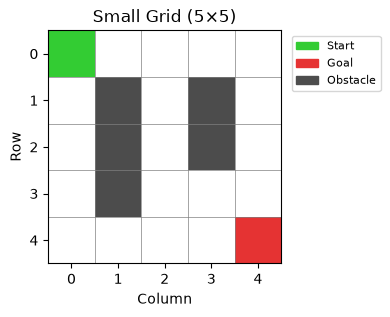

Neighbours of (0, 0): [(1, 0), (0, 1)]
Neighbours of (2, 2): [(1, 2), (3, 2)]
Neighbours of (1, 1): []  (obstacle — no neighbours)


In [50]:
# Small grid (5x5) with some obstacles
small_obstacles = {(1, 1), (2, 1), (3, 1), (1, 3), (2, 3)}
small_grid = GridWorld(5, 5, obstacles=small_obstacles)

small_grid.visualise(start=(0, 0), goal=(4, 4), title="Small Grid (5×5)")

# Try getting neighbours
print(f"Neighbours of (0, 0): {small_grid.get_neighbours(0, 0)}")
print(f"Neighbours of (2, 2): {small_grid.get_neighbours(2, 2)}")
print(f"Neighbours of (1, 1): {small_grid.get_neighbours(1, 1)}  (obstacle — no neighbours)")

**Key takeaway:** `get_neighbours` returns a list of `(row, col)` tuples, exactly like the adjacency lists you built in P1. The only difference is that nodes are grid positions instead of letters. BFS doesn't care: it works on any graph.

In your hand trace, nodes were letters like `"S"` and `"A"`. On the grid, nodes are tuples like `(0, 0)` and `(2, 3)`. The BFS algorithm treats them identically: it just asks "have I seen this node before?" and "what are its neighbours?"

---

## Part 2: Implement BFS

You now have the tools (`Queue`, `GridWorld`) and a hand trace. Your job: **translate the BFS pseudocode from the W2 lecture into Python**.

The lecture slides contain a `function BFS(start, goal):` pseudocode block in neutral notation (`frontier <- Queue()`, `visited.add(neighbour)`, etc.). Implementing BFS means mapping each line of that pseudocode to the corresponding Python call using the helpers in `p2_helpers.py`.

Think in terms of three blocks:

1. **Initialise:** what state do you set up before the loop? (frontier, `visited` set, `came_from` dict, counter)
2. **Loop:** what happens on each iteration? (dequeue, goal check, expand neighbours)
3. **Reconstruct:** how do you turn `came_from` back into a path? (already done for you at the end)

> **Why two structures, not one?**
> - `visited` answers *"have I seen this node before?"* (it stops you re-expanding the same cell).
> - `came_from` answers *"how did I get here?"* (it lets the path be reconstructed at the end).
>
> These are two different questions, so we keep two different structures. Your hand trace already separated them into a *Visited* column and an *Exploration order*, so your code should match. (You'll see "combined" implementations online that use `came_from` for both; they work, but they conflate two concepts; the milestone discussion will probe which form you wrote and why.)

> **About `nodes_expanded`:** Increment it each time you dequeue a node from the frontier (one "expansion" per dequeue). You'll report this number in Part 5.

> **About the lecture pseudocode:** The slide pseudocode is the algorithm; your job is to write the Python that mirrors it. If you can't recall the pseudocode, re-watch the relevant lecture segment before starting; the notebook intentionally does not duplicate the algorithm spec.


In [51]:
def bfs_search(grid_world, start, goal):
    """Run BFS on a GridWorld from start to goal.

    Args:
        grid_world: A GridWorld object.
        start: (row, col) tuple — the starting cell.
        goal: (row, col) tuple — the goal cell.

    Returns:
        path: List of (row, col) tuples from start to goal, or None.
        explored: Set of all (row, col) tuples that were explored.
        nodes_expanded: Number of nodes dequeued from the frontier.
    """
    # --- YOUR CODE STARTS HERE ---
    # Translate the BFS pseudocode from the lecture slides
    # (attempt 3 — the full algorithm). The Queue, GridWorld,
    # and reconstruct_path helpers are imported at the top.

    # 1. Set up your state
    frontier= Queue()
    frontier.enqueue(start)
    visited=set()
    visited.add(start)
    came_from={}
    came_from[start]=None
    nodes_expanded=0
    # 2. Search
    while not frontier.is_empty():
        current=frontier.dequeue()
        nodes_expanded+=1
        for neighbour in grid_world.get_neighbours(current[0],current[1]):#get the all option in the current node
            if neighbour not in visited:#doesn't go bacl to previous node
                came_from[neighbour]=current #create path
                visited.add(neighbour)
                if neighbour==goal:
                    path = reconstruct_path(came_from, start, goal)
                    explored = set(visited)
                    return path, explored, nodes_expanded
                frontier.enqueue(neighbour)
                

    # 3. Reconstruct (provided below — do not modify)

    # --- YOUR CODE ENDS HERE ---

    path = reconstruct_path(came_from, start, goal)
    explored = set(visited)

    return path, explored, nodes_expanded


### Hints (open only if stuck)

<details>
<summary><b>Hint 1:</b> Initialise the frontier, visited set, came_from dict</summary>

```python
frontier = Queue()
frontier.enqueue(start)
visited = {start}
came_from = {start: None}
nodes_expanded = 0
```

`visited` answers "have I seen this?"; `came_from` answers "how did I get here?". Both start with `start` already recorded.
</details>

<details>
<summary><b>Hint 2:</b> The main loop skeleton</summary>

```python
while not frontier.is_empty():
    current = frontier.dequeue()
    nodes_expanded += 1
    if current == goal:
        break
    # expand neighbours below
```
</details>

<details>
<summary><b>Hint 3:</b> Unpack the cell coordinates</summary>

Cells are `(row, col)` tuples. Unpack with `row, col = current` so you can call `grid_world.get_neighbours(row, col)`.
</details>

<details>
<summary><b>Hint 4:</b> Expanding neighbours</summary>

For each neighbour returned by `get_neighbours`, check whether it has been visited. If not, mark it visited, enqueue it, and record where it came from:

```python
for neighbour in grid_world.get_neighbours(row, col):
    if neighbour not in visited:
        visited.add(neighbour)
        frontier.enqueue(neighbour)
        came_from[neighbour] = current
```
</details>

> **No full-skeleton hint.** The four hints above scaffold each component of the loop: initialisation, loop shape, tuple unpacking, neighbour expansion. Assembling them into a working `bfs_search` body IS the lesson. If you have all four hints open and you're still stuck, ask a tutor in lab; don't ask the LLM. The milestone discussion will probe whether you wrote the assembly yourself.


---

## Part 3: Run BFS on the small grid (5×5)

Run the cell below to test your implementation on the small grid. You should see a path from (0,0) to (4,4) that avoids all obstacles.

Path found! Length: 9 steps
Path: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
Nodes expanded: 18
Total cells explored: 20


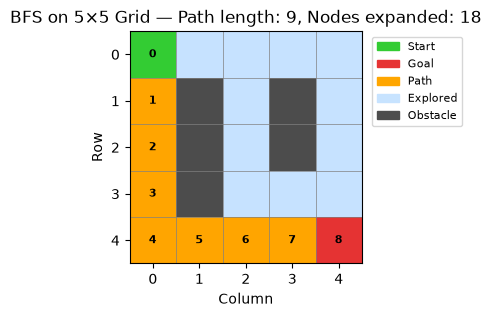

In [52]:
start = (0, 0)
goal = (4, 4)

path, explored, nodes_expanded = bfs_search(small_grid, start, goal)

if path:
    print(f"Path found! Length: {len(path)} steps")
    print(f"Path: {path}")
    print(f"Nodes expanded: {nodes_expanded}")
    print(f"Total cells explored: {len(explored)}")
    small_grid.visualise(path=path, explored=explored, start=start, goal=goal,
                         title=f"BFS on 5×5 Grid — Path length: {len(path)}, Nodes expanded: {nodes_expanded}")
else:
    print("No path found! Check your BFS implementation.")

**Check your results.** If your BFS is correct:
- The path should be the **shortest** path from (0,0) to (4,4)
- The explored cells (light blue) should spread out layer by layer from the start
- The path (orange) should avoid all obstacles (dark grey)

If you get "No path found", check that you're adding neighbours to the frontier and updating `came_from`.

---

## Part 4: Run BFS on the large grid (10×10)

Now test on a larger grid with more obstacles.

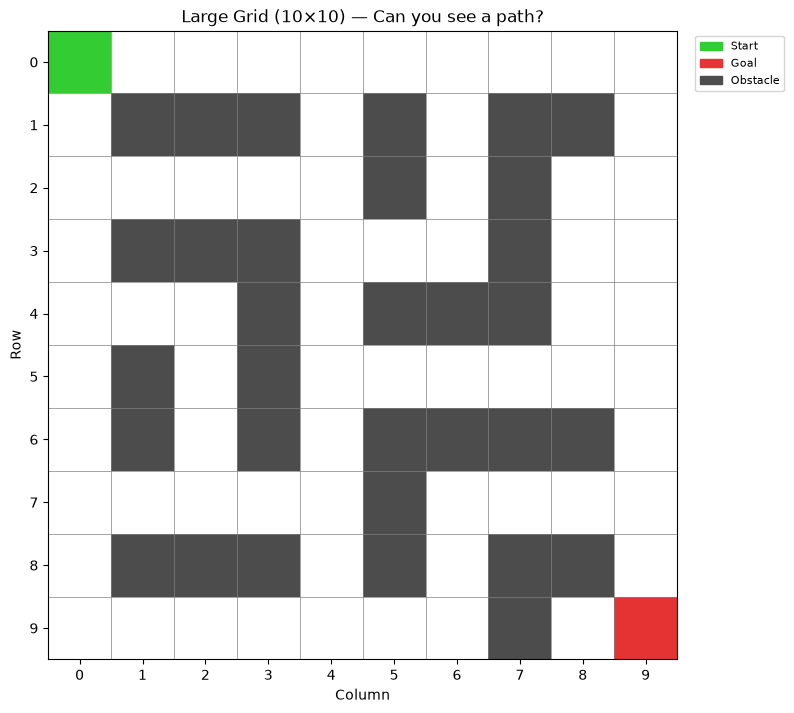

In [53]:
# Large grid (10x10) with obstacles forming a maze-like pattern
large_obstacles = {
    (1, 1), (1, 2), (1, 3), (1, 5), (1, 7), (1, 8),
    (2, 5), (2, 7),
    (3, 1), (3, 2), (3, 3), (3, 7),
    (4, 3), (4, 5), (4, 6), (4, 7),
    (5, 1), (5, 3),
    (6, 1), (6, 3), (6, 5), (6, 6), (6, 7), (6, 8),
    (7, 5),
    (8, 1), (8, 2), (8, 3), (8, 5), (8, 7), (8, 8),
    (9, 7),
}
large_grid = GridWorld(10, 10, obstacles=large_obstacles)

# First, look at the grid before solving it
large_grid.visualise(start=(0, 0), goal=(9, 9), title="Large Grid (10×10) — Can you see a path?")

Look at the grid above. Can you visually trace a path from the green cell (0,0) to the red cell (9,9)? Now let BFS find it:

Path found! Length: 19 steps
Nodes expanded: 64
Total cells explored: 67
Grid size: 100 cells (32 obstacles)


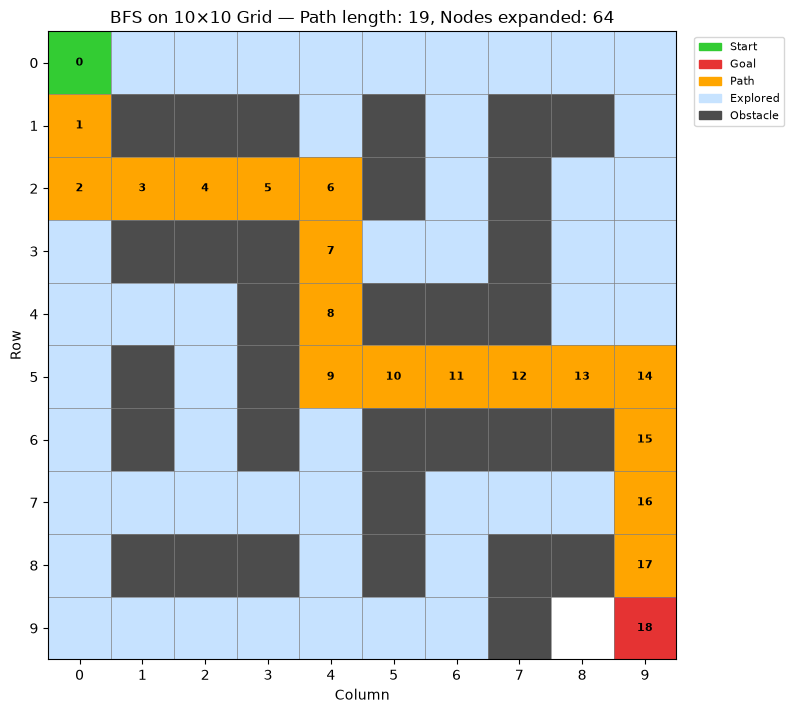

In [54]:
start = (0, 0)
goal = (9, 9)

path, explored, nodes_expanded = bfs_search(large_grid, start, goal)

if path:
    print(f"Path found! Length: {len(path)} steps")
    print(f"Nodes expanded: {nodes_expanded}")
    print(f"Total cells explored: {len(explored)}")
    print(f"Grid size: {large_grid.rows * large_grid.cols} cells ({len(large_obstacles)} obstacles)")
    large_grid.visualise(path=path, explored=explored, start=start, goal=goal,
                         title=f"BFS on 10×10 Grid — Path length: {len(path)}, Nodes expanded: {nodes_expanded}")
else:
    print("No path found!")

---

## Part 5: Record your results

Fill in the comparison table below (double-click this cell to edit).

| | Small Grid (5×5) | Large Grid (10×10) |
|---|---|---|
| **Path length** | __9_ | __19_ |
| **Nodes expanded** | __18_ | __64_ |
| **Grid size** (total cells) | 25 | 100 |
| **Obstacles** | 5 | 31 |
| **Walkable cells** | 20 | 69 |

**Reflect on these numbers:**

1. Did BFS explore most of the walkable cells, or only a few? Why?
2. How does the number of nodes expanded compare to the grid size? What does this tell you about BFS's efficiency?
3. Would a different start-goal pair change how many nodes BFS expands? Why or why not?

Write your answers below (double-click to edit):

_Your answers here._
it explore most of the walkable cells, because it is like walking in same steps in different direction, comaparing the nodes expanded and walkable cells, we can observe that it go through most of the cells, so it has bad efficiency. If the goal and start is very close than the nodes expands will be decreased dramatically. 

---

## Part 6: Depth-First Search (DFS)

You've just implemented BFS. Depth-first search differs by **a single decision**: replace the queue with a **stack**. The same algorithm shape, with one data-structure swap, produces a very different exploration order, and different tradeoffs.

- BFS (queue, FIFO): explores layer by layer; guarantees the shortest path.
- DFS (stack, LIFO): dives along one branch as deep as it can go; finds *a* path, not necessarily the shortest.

**Translate the DFS pseudocode from the W2 lecture into Python.** It is the BFS pseudocode with three substitutions: `Queue` → `Stack`, `enqueue` → `push`, `dequeue` → `pop`. The `visited` / `came_from` logic is identical. Adapt your `bfs_search` rather than starting over.

> **Why a stack?** Pushing all neighbours and then popping the most-recently-added one means DFS commits to the latest discovered branch before checking earlier ones: depth-first behaviour.


In [55]:
def dfs_search(grid_world, start, goal):
    """Run DFS on a GridWorld from start to goal.

    Uses a Stack (LIFO) instead of a Queue (FIFO). Same algorithm shape;
    different exploration order.

    Args:
        grid_world: A GridWorld instance.
        start: (row, col) tuple -- the starting cell.
        goal:  (row, col) tuple -- the goal cell.

    Returns:
        (path, explored, nodes_expanded) -- same shape as bfs_search.
    """
    # --- YOUR CODE STARTS HERE ---
    # Translate the DFS pseudocode from the lecture slides. The structure
    # is identical to your bfs_search; only the data structure changes.

    # 1. Set up your state
    frontier = Stack()
    frontier.push(start)
    visited=set()
    came_from={}
    came_from[start]=None
    nodes_expanded=0
    # 2. Search
    while not frontier.is_empty():
        current=frontier.pop()
        if current in visited: 
            continue
        visited.add(current)
        nodes_expanded+=1
        if current==goal:
            path = reconstruct_path(came_from, start, goal)
            explored = set(visited)
            return path, explored, nodes_expanded
        for neighbour in grid_world.get_neighbours(current[0],current[1]):#get the all option in the current node
            if neighbour not in visited:#doesn't go bacl to previous node
                came_from[neighbour]=current #create path
            frontier.push(neighbour)

    # 3. Reconstruct (provided below -- do not modify)

    # --- YOUR CODE ENDS HERE ---

    path = reconstruct_path(came_from, start, goal)
    explored = set(visited)

    return path, explored, nodes_expanded

### Hints (open only if stuck)

<details>
<summary><b>Hint 1:</b> Initialise the frontier, visited set, came_from dict</summary>

```python
frontier = Stack()
frontier.push(start)
visited = {start}
came_from = {start: None}
nodes_expanded = 0
```

Compare to BFS: same shape, only the data structure changes (`Stack` instead of `Queue`).
</details>

<details>
<summary><b>Hint 2:</b> The main loop skeleton</summary>

```python
while not frontier.is_empty():
    current = frontier.pop()
    nodes_expanded += 1
    if current == goal:
        break
    # expand neighbours below
```

This is the same shape as BFS; only the method name differs (`pop` for a Stack vs `dequeue` for a Queue).
</details>

<details>
<summary><b>Hint 3:</b> Unpack the cell coordinates</summary>

Cells are `(row, col)` tuples. Unpack with `row, col = current` so you can call `grid_world.get_neighbours(row, col)`.
</details>

> **No full-skeleton hint.** The three hints above scaffold each component of the loop: initialisation, loop shape, tuple unpacking. The neighbour-expansion step is your work. Translate the lecture pseudocode for that part. If all three hints are open and you are still stuck, ask a tutor in lab; do not ask the LLM. The milestone discussion will probe whether you wrote the neighbour expansion yourself.

DFS — 5×5 grid
  Path length:    13
  Nodes expanded: 13
  Cells in explored set: 13


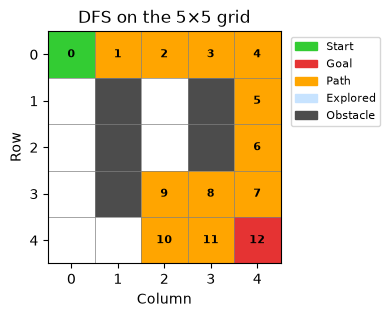


DFS — 10×10 grid
  Path length:    23
  Nodes expanded: 67
  Cells in explored set: 67


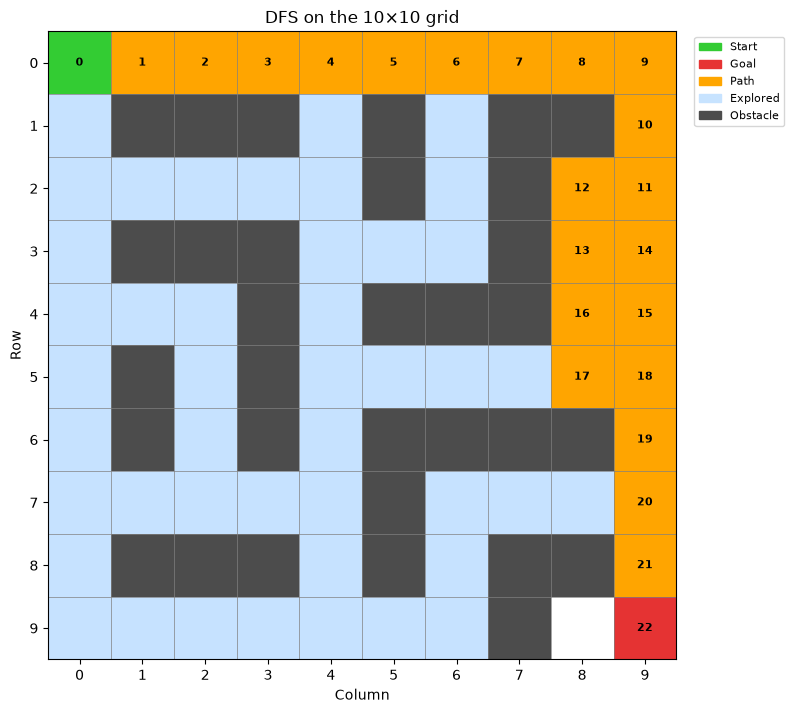

In [56]:
# Run DFS on the small (5×5) grid first, then the large (10×10) grid.
# Both grids are the same ones you ran BFS on, so you can compare directly.

start = (0, 0)

# --- Small grid ---
goal_small = (4, 4)
dfs_path_s, dfs_explored_s, dfs_expanded_s = dfs_search(small_grid, start, goal_small)
print(f"DFS — 5×5 grid")
print(f"  Path length:    {len(dfs_path_s) if dfs_path_s else 'no path'}")
print(f"  Nodes expanded: {dfs_expanded_s}")
print(f"  Cells in explored set: {len(dfs_explored_s)}")
small_grid.visualise(path=dfs_path_s, explored=dfs_explored_s,
                     start=start, goal=goal_small,
                     title="DFS on the 5×5 grid")

# --- Large grid ---
goal_large = (9, 9)
dfs_path_l, dfs_explored_l, dfs_expanded_l = dfs_search(large_grid, start, goal_large)
print(f"\nDFS — 10×10 grid")
print(f"  Path length:    {len(dfs_path_l) if dfs_path_l else 'no path'}")
print(f"  Nodes expanded: {dfs_expanded_l}")
print(f"  Cells in explored set: {len(dfs_explored_l)}")
large_grid.visualise(path=dfs_path_l, explored=dfs_explored_l,
                     start=start, goal=goal_large,
                     title="DFS on the 10×10 grid")


---

## Part 7: BFS vs DFS: same grid, different paths (P2.4)

So far BFS and DFS may have looked similar on the 5×5 and 10×10 grids. The dead-end grid below is designed to expose the difference: a deep cul-de-sac that DFS, because it commits to the most recently discovered branch, dives into before finding the goal.

Run **both** BFS and DFS on this single grid and compare:
- **Path length:** how many cells from start to goal?
- **Nodes expanded:** how many cells did the algorithm remove from the frontier?
- **Cells in the explored set:** how much of the maze did the algorithm touch?


                          BFS      DFS
Path length                13       23
Nodes expanded             25       23
Cells in explored set      28       23


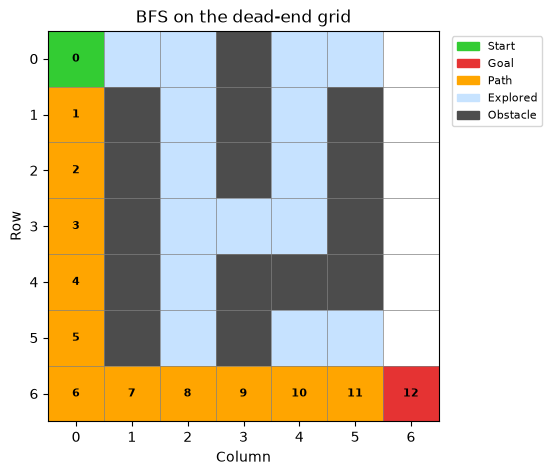

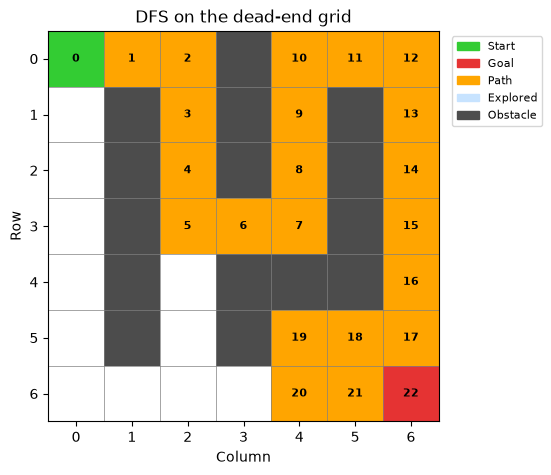

In [57]:
from p2_helpers import make_dead_end_grid

dead_end = make_dead_end_grid()
start = (0, 0)
goal = (6, 6)

bfs_path, bfs_explored, bfs_expanded = bfs_search(dead_end, start, goal)
dfs_path, dfs_explored, dfs_expanded = dfs_search(dead_end, start, goal)

print(f"{'':<22} {'BFS':>6}   {'DFS':>6}")
print(f"{'Path length':<22} {len(bfs_path):>6}   {len(dfs_path):>6}")
print(f"{'Nodes expanded':<22} {bfs_expanded:>6}   {dfs_expanded:>6}")
print(f"{'Cells in explored set':<22} {len(bfs_explored):>6}   {len(dfs_explored):>6}")

dead_end.visualise(path=bfs_path, explored=bfs_explored,
                   start=start, goal=goal,
                   title="BFS on the dead-end grid")
dead_end.visualise(path=dfs_path, explored=dfs_explored,
                   start=start, goal=goal,
                   title="DFS on the dead-end grid")


**P2.4: Write your comparison.** Fill in the table below using the numbers printed above, then answer the two questions in 2–3 sentences total.

| Metric | BFS | DFS |
|---|---|---|
| Path length |13 |23 |
| Nodes expanded |25 |23 |
| Cells in explored set |28 |23 |

1. Which algorithm found the **shorter path** on this grid? Will that always be the case for BFS? Why?
2. Which algorithm **expanded fewer nodes**? Is "fewer nodes expanded" the same as "better"? When might DFS expand fewer nodes than BFS, and when might it expand more?

*(Write your 2–3 sentence response in this markdown cell.)*
BFS will always find the shortest path on the grid, because it explore all the nodes on the same step first, then return the result once it hits the goal. In other word, Bfs spend more expanding nodes for shortest path, and DFS find a valid path but with expanding fewer nodes. DFS will expand more if first 3 out of 4 option is a dead end, then it will expand more.

---

### P2.5: Reflection: "When an AI wins, does it matter how?" (150–250 words)

Write a short reflective response (150–250 words):

> *"When an AI wins, does it matter how?"*

Think about Deep Blue. It won by brute-force search, evaluating 200 million positions per second. Did it "understand" chess? Does that matter? What counts as a meaningful victory? Connect this to the BFS-vs-DFS contrast you just observed: brute-force exploration patterns matter even at this small scale.

> *(Optional: this week ran a Kialo debate on the motion "Deep Blue's win tells us nothing about intelligence." You may draw on a peer's argument in your reflection.)*

> **Keep it personal.** No AI-generated responses. We want your genuine thinking. A rough, honest account is better than a polished, generic one.

*Write your response below or in a separate document.*

---

**Your response:**

*(Write here)*
I don't think how AI beat humans matters. Because it is just an implementation of technology, not a representation of intelligence. Even though it seems like the AI beats humans, credit should be given to the people who develop the algorithm and find a way to break the game. In addition, I don't think computers understand any of the games. If you think at the hardware level, like the computing component, it is no way near intelligent, because it keeps doing the same things over and over again. At the software level, it is the algorithm we design to make it seem "intelligent", or implement a method that was given up by us because it is too repetitive or it took too much memory. 

---

## Part 8: Understanding BFS & DFS (quiz)

Run the quiz below to check your understanding before your milestone discussion.


In [ ]:
from jupyterquiz import display_quiz

bfs_quiz = [
    {
        "question": "Why does BFS guarantee finding the shortest path in an unweighted graph?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "Because the queue (FIFO) ensures nodes are explored in the order they were discovered — closest nodes first.", "correct": True, "feedback": "Correct! The FIFO property means BFS explores all nodes at distance 1 before distance 2, distance 2 before distance 3, etc."},
            {"answer": "Because BFS always picks the node with the lowest cost.", "correct": False, "feedback": "That's a different algorithm (Dijkstra's / uniform-cost search). BFS doesn't consider costs — it uses discovery order."},
            {"answer": "Because BFS explores every single node in the graph.", "correct": False, "feedback": "BFS might not explore every node (it stops when it finds the goal). The shortest-path guarantee comes from the FIFO order, not from exhaustive search."},
            {"answer": "Because BFS uses a stack to backtrack efficiently.", "correct": False, "feedback": "BFS uses a queue, not a stack. A stack would give you DFS, which does NOT guarantee shortest paths."}
        ]
    },
    {
        "question": "What would happen if you removed the visited check (<code>if neighbour not in came_from</code>) from BFS?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "BFS would loop forever on graphs with cycles.", "correct": True, "feedback": "Correct! Without the visited check, BFS would keep re-adding the same nodes to the frontier, creating an infinite loop."},
            {"answer": "BFS would still work but be slightly slower.", "correct": False, "feedback": "On a graph with cycles, it wouldn't just be slower — it would never terminate."},
            {"answer": "BFS would find a longer path.", "correct": False, "feedback": "It wouldn't find any path — it would loop forever on cyclic graphs."},
            {"answer": "Nothing would change.", "correct": False, "feedback": "Try tracing BFS on a graph with a cycle (e.g., A→B→A) without a visited check. What happens?"}
        ]
    },
    {
        "question": "If you replaced the Queue with a Stack in BFS, what algorithm would you get?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "Depth-First Search (DFS)", "correct": True, "feedback": "Correct! Same structure, different data structure, completely different behaviour. DFS dives deep before backtracking."},
            {"answer": "A faster version of BFS", "correct": False, "feedback": "A stack gives LIFO order, which fundamentally changes the exploration pattern — you'd get DFS."},
            {"answer": "Dijkstra's algorithm", "correct": False, "feedback": "Dijkstra uses a priority queue (sorted by cost), not a stack."},
            {"answer": "The same algorithm (BFS)", "correct": False, "feedback": "The choice of data structure is what defines BFS vs DFS. Queue = BFS, Stack = DFS."}
        ]
    }
]

display_quiz(bfs_quiz, shuffle_answers=True)

<IPython.core.display.Javascript object>

: 

---

## Submission checklist

- [x ] **P2.1:** Hand trace of BFS on the 7-node graph (photographed)
- [x ] **P2.2:** BFS implementation working on both grids (this notebook)
- [x ] **P2.3:** DFS implementation working on both grids (this notebook)
- [x ] **P2.4:** BFS vs DFS comparison table filled in on the dead-end grid + 2–3 sentence observation
- [x ] **P2.5:** Reflection on "When an AI wins, does it matter how?" (150–250 words, separate document)
- [x ] Results table filled in (Part 5)
- [x ] Reflection prompts answered (Part 5)
- [x ] **Kernel → Restart and Run All** to confirm every cell runs without errors before submitting
- [x ] All files uploaded to OnTrack and marked **Ready for Feedback**
- [x ] Milestone discussion booked with tutor

---

*FIT1061 Pass Task P2: BFS & DFS*
